<a href="https://colab.research.google.com/github/chahipatel/heart-disease-prediction/blob/main/heartdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


**Data Collection**

In [ ]:
ds = pd.read_csv("heart.csv")

**EDA**

In [ ]:
ds.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
ds.shape

(918, 12)

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
ds.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
ds.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


**Data Cleaning**

In [ ]:
ds.duplicated().sum()

np.int64(0)

In [ ]:
ds.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


**Data Preprocessing**

In [ ]:
ds_cleaned = pd.get_dummies(ds,drop_first=True)


In [ ]:
ds_cleaned

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [ ]:
ds_encode = ds_cleaned.astype(int)

In [ ]:
ds_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
ds_cleaned[numerical_cols] = scaler.fit_transform(ds_cleaned[numerical_cols])
ds_cleaned.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.491752,-0.171961,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.129513,0.770188,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.302825,0.139040,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.951331,-0.034755,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True


In [ ]:
ds_cleaned.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

**Feature Engineering**

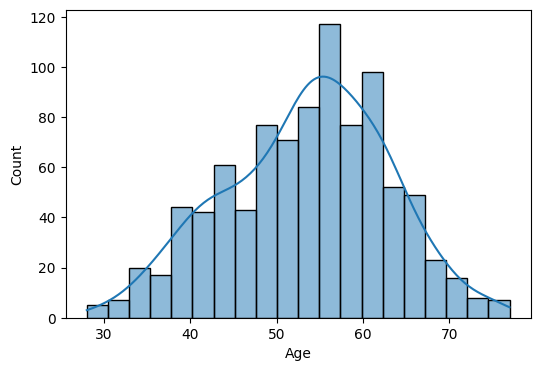

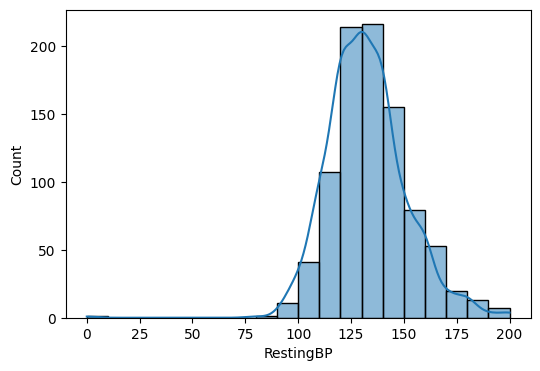

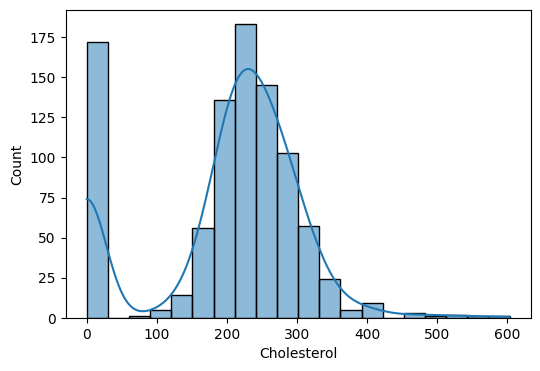

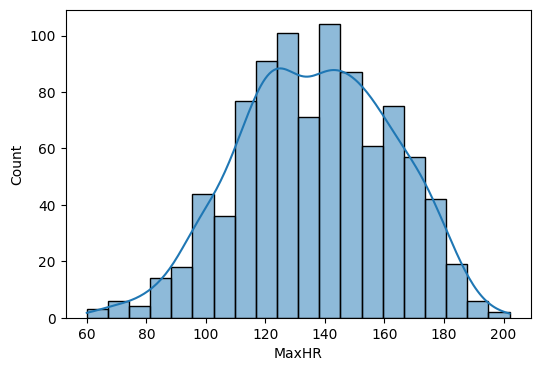

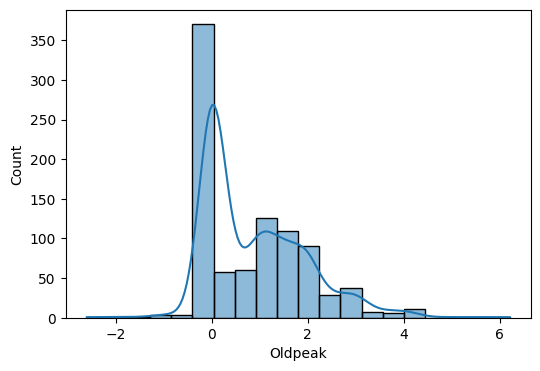

In [ ]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(ds[col],kde = True,bins = 20)

<Axes: xlabel='Sex', ylabel='count'>

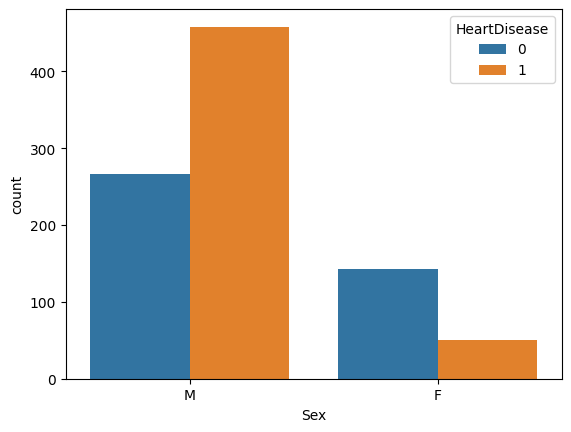

In [ ]:
sns.countplot(x = ds['Sex'],hue = ds['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

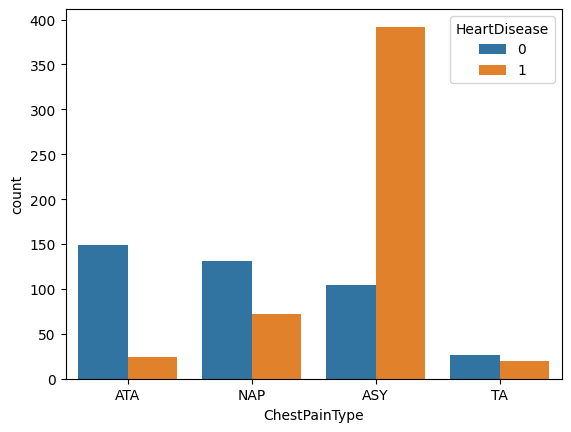

In [ ]:
sns.countplot(x = ds['ChestPainType'],hue = ds['HeartDisease'])

<Axes: xlabel='RestingECG', ylabel='count'>

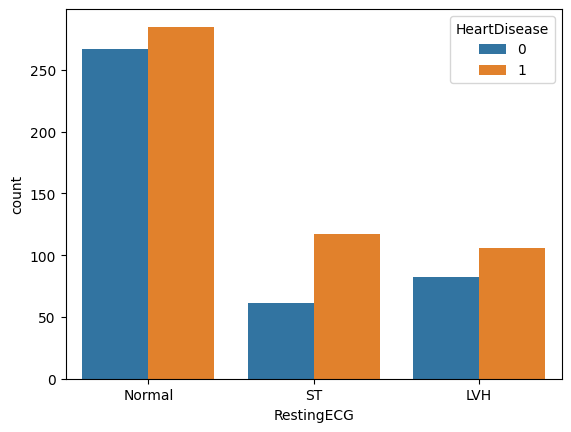

In [ ]:
sns.countplot(x = ds['RestingECG'],hue = ds['HeartDisease'])

<Axes: xlabel='ExerciseAngina', ylabel='count'>

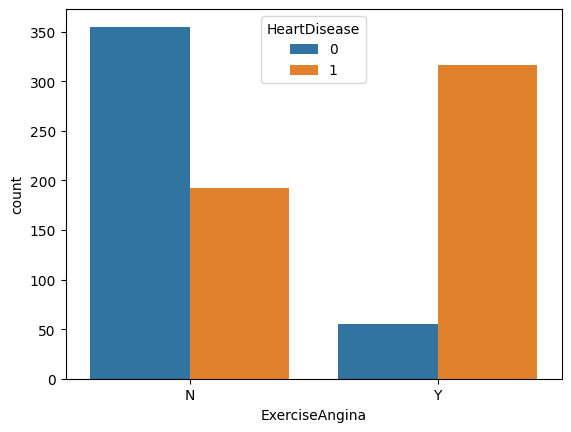

In [ ]:
sns.countplot(x = ds['ExerciseAngina'],hue = ds['HeartDisease'])

<Axes: xlabel='ST_Slope', ylabel='count'>

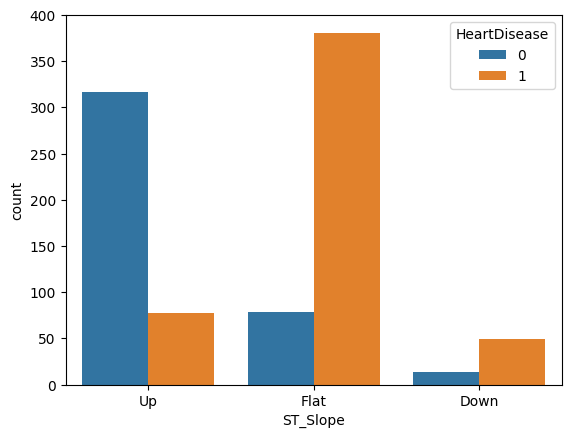

In [ ]:
sns.countplot(x = ds['ST_Slope'],hue = ds['HeartDisease'])

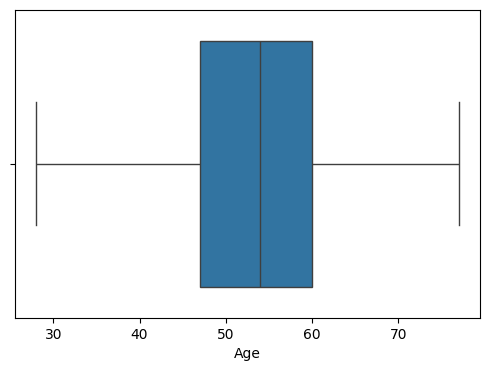

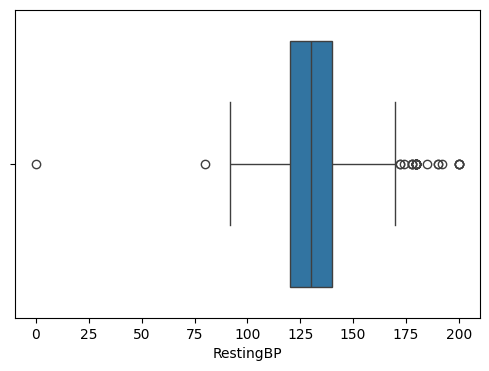

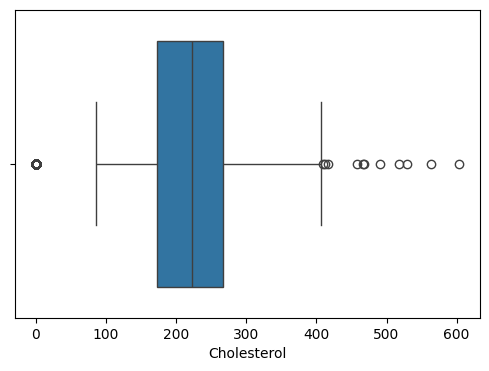

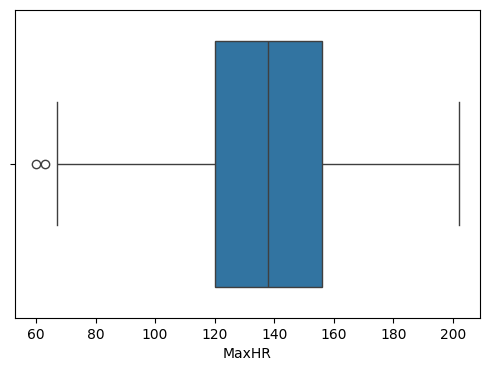

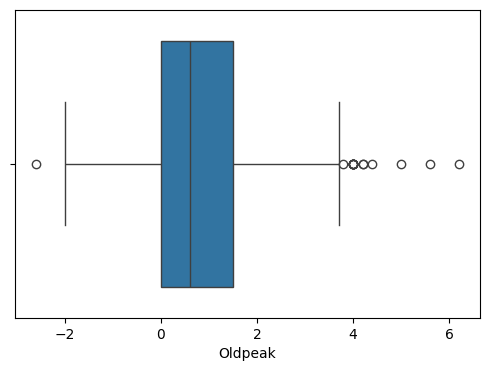

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=ds[col])


<Axes: xlabel='HeartDisease', ylabel='Age'>

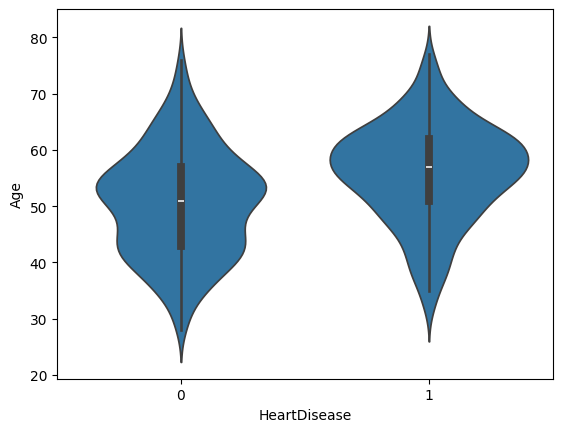

In [ ]:
sns.violinplot(x='HeartDisease', y='Age', data=ds)

<Axes: >

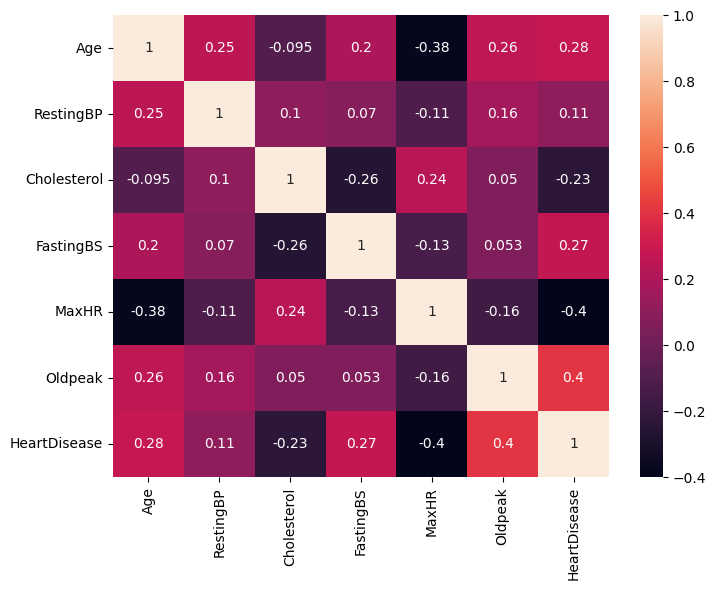

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(ds.corr(numeric_only=True),annot=True)

**Split The Dataset**

In [ ]:
X = ds_cleaned.drop('HeartDisease', axis=1)
y = ds_cleaned['HeartDisease']

**Model Selection And Training**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**1.Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

In [ ]:
y_test

,HeartDisease
668,0
30,1
377,1
535,1
807,0
...,...
211,1
745,1
584,1
878,0


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report

In [ ]:
accuracy_score(y_test,y_pred)

0.8532608695652174

In [ ]:
confusion_matrix(y_test,y_pred)

array([[67, 10],
       [17, 90]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



**2.K-Nearest Neighbors (KNN)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors= 5)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(X_test)

In [ ]:
y_pred_knn

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1])

In [ ]:
accuracy_score(y_test,y_pred_knn)

0.8260869565217391

In [ ]:
confusion_matrix(y_test,y_pred_knn)

array([[61, 16],
       [16, 91]])

In [ ]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        77
           1       0.85      0.85      0.85       107

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



**3.Gaussian Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred_NB = model_NB.predict(X_test)

In [ ]:
y_pred_NB

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1])

In [ ]:
accuracy_score(y_test,y_pred_NB)

0.8586956521739131

In [ ]:
confusion_matrix(y_test,y_pred_NB)

array([[68,  9],
       [17, 90]])

In [ ]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



**4.Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model_DT = DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_DT = model_DT.predict(X_test)

In [ ]:
y_pred_DT

array([0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1])

In [ ]:
accuracy_score(y_test,y_pred_DT)

0.8315217391304348

In [ ]:
confusion_matrix(y_test,y_pred_DT)

array([[62, 15],
       [16, 91]])

In [ ]:
print(classification_report(y_test,y_pred_DT))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        77
           1       0.86      0.85      0.85       107

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



**5.Support Vector Machine**

In [ ]:
from sklearn.svm import SVC

In [ ]:
model_svm = SVC(kernel = 'linear')
model_svm.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred_svc = model_svm.predict(X_test)

In [ ]:
y_pred_svc

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

In [ ]:
accuracy_score(y_test,y_pred_svc)

0.8532608695652174

In [ ]:
confusion_matrix(y_test,y_pred_svc)

array([[67, 10],
       [17, 90]])

In [ ]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



**Ensemble Learning**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [ ]:
from xgboost import XGBClassifier

In [ ]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
ada_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
y_pred = ada_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
accuracy

0.8532608695652174

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)


In [ ]:
gb_model.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred = gb_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
accuracy

0.8641304347826086

In [ ]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42)


In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
accuracy

0.8804347826086957

**Grid Search CV**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
classifier = GridSearchCV((model_svm),{
    'C' : [1,10,20,30],
    'kernel' :['rbf','linear'],
},cv = 5,return_train_score = False)

In [ ]:
classifier.fit(X,y)

GridSearchCV(cv=5, estimator=SVC(kernel='linear'),
             param_grid={'C': [1, 10, 20, 30], 'kernel': ['rbf', 'linear']})

In [ ]:
classifier.cv_results_

{'mean_fit_time': array([0.02029343, 0.01933842, 0.02145028, 0.05974793, 0.02559814,
        0.09369206, 0.02727661, 0.13703871]),
 'std_fit_time': array([0.00396941, 0.00142515, 0.00139752, 0.00719674, 0.00255307,
        0.00770598, 0.00295054, 0.01471449]),
 'mean_score_time': array([0.00805655, 0.00468669, 0.00641108, 0.00502472, 0.00629821,
        0.00431066, 0.00683589, 0.00459785]),
 'std_score_time': array([0.00136232, 0.00032256, 0.00027729, 0.00100431, 0.00032357,
        0.00026724, 0.00068113, 0.00054921]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20, 30, 30],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear',
                    'rbf', 'linear'],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'C': 1, 'kernel': 'rbf'},
  {'C

In [ ]:
results = pd.DataFrame(classifier.cv_results_)

In [ ]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.020293,0.003969,0.008057,0.001362,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.869565,0.875000,0.842391,0.825137,0.743169,0.831053,0.047543,1
1,0.019338,0.001425,0.004687,0.000323,1,linear,"{'C': 1, 'kernel': 'linear'}",0.858696,0.842391,0.836957,0.852459,0.743169,0.826734,0.042464,5
2,0.021450,0.001398,0.006411,0.000277,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.842391,0.842391,0.820652,0.803279,0.781421,0.818027,0.023459,6
3,0.059748,0.007197,0.005025,0.001004,10,linear,"{'C': 10, 'kernel': 'linear'}",0.858696,0.847826,0.842391,0.846995,0.743169,0.827815,0.042660,2
4,0.025598,0.002553,0.006298,0.000324,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.826087,0.831522,0.804348,0.775956,0.797814,0.807145,0.020103,7
5,0.093692,0.007706,0.004311,0.000267,20,linear,"{'C': 20, 'kernel': 'linear'}",0.858696,0.847826,0.842391,0.846995,0.743169,0.827815,0.042660,2
6,0.027277,0.002951,0.006836,0.000681,30,rbf,"{'C': 30, 'kernel': 'rbf'}",0.831522,0.820652,0.793478,0.748634,0.781421,0.795141,0.029422,8
7,0.137039,0.014714,0.004598,0.000549,30,linear,"{'C': 30, 'kernel': 'linear'}",0.858696,0.847826,0.842391,0.846995,0.743169,0.827815,0.042660,2


In [ ]:
results[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.831053
1,1,linear,0.826734
2,10,rbf,0.818027
3,10,linear,0.827815
4,20,rbf,0.807145
5,20,linear,0.827815
6,30,rbf,0.795141
7,30,linear,0.827815


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
classifier_r = RandomizedSearchCV((model_svm),{
    'C' : [1,10,20,30],
    'kernel' :['rbf','linear'],
},n_iter = 4,cv = 5,return_train_score = False)

In [ ]:
classifier_r.fit(X,y)

RandomizedSearchCV(cv=5, estimator=SVC(kernel='linear'), n_iter=4,
                   param_distributions={'C': [1, 10, 20, 30],
                                        'kernel': ['rbf', 'linear']})

In [ ]:
results = pd.DataFrame(classifier_r.cv_results_)

In [ ]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kernel,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.029332,0.002444,0.011101,0.000626,rbf,1,"{'kernel': 'rbf', 'C': 1}",0.869565,0.875000,0.842391,0.825137,0.743169,0.831053,0.047543,1
1,0.043364,0.005980,0.010713,0.001277,rbf,30,"{'kernel': 'rbf', 'C': 30}",0.831522,0.820652,0.793478,0.748634,0.781421,0.795141,0.029422,4
2,0.030419,0.003508,0.006692,0.000484,linear,1,"{'kernel': 'linear', 'C': 1}",0.858696,0.842391,0.836957,0.852459,0.743169,0.826734,0.042464,3
3,0.190585,0.047945,0.040173,0.069313,linear,30,"{'kernel': 'linear', 'C': 30}",0.858696,0.847826,0.842391,0.846995,0.743169,0.827815,0.042660,2


In [ ]:
results[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.831053
1,30,rbf,0.795141
2,1,linear,0.826734
3,30,linear,0.827815


**Joblib**

In [ ]:
import joblib
joblib.dump(xgb_model,'XGB.pkl')


['XGB.pkl']

In [ ]:
joblib.dump(ds_cleaned,'scaler.pkl')


['scaler.pkl']

In [ ]:
joblib.dump(ds_encode,'columns.pkl')

['columns.pkl']

In [ ]:
import joblib

joblib.dump(xgb_model, "XGB.pkl")
joblib.dump(X.columns, "columns.pkl")

print("Saved successfully ✅")

Saved successfully ✅


In [ ]:
import os
print(os.listdir())

['.config', 'XGB.pkl', 'scaler.pkl', 'heart.csv', 'columns.pkl', 'sample_data']
